
<h1 align="center"> k-Nearest Neighbors algorithm and hyperparameter tuning </h1>

<pre align="left"> September 10th 2025               <i> Author: Igor Colin </i></pre>
* * *

**Goals**
- Implement a **k-Nearest Neighbors (kNN)** classifier **from scratch** in NumPy.
- Use the **Breast Cancer Wisconsin** dataset (scikit-learn).
- Measure and compare **training time** and **inference time** **as a function of the training sample size**.
- Analyze **train/test accuracy** as a function of **k**.
- Visualize and discuss **overfitting vs underfitting** with 2D decision boundaries.

> A 🔧 **Question** indicates that you need to fill **TODO** blocks in the following cell.

> Whenever you encounter a 🧠 **Question**, answer it in the same block.

## 1) Setup

In [1]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

import time

np.random.seed(42)

def describe_split(X_train, X_test, y_train, y_test):
    print(f"Train: X={X_train.shape}, y={y_train.shape} | Test: X={X_test.shape}, y={y_test.shape}")


## 2) Load & preprocess the data

In [2]:

data = load_breast_cancer()
X = data.data.astype(float)
y = data.target.astype(int)
feature_names = data.feature_names
target_names = data.target_names

print("Classes:", list(target_names))
print("Num samples:", X.shape[0], "| Num features:", X.shape[1])

# Standardize (important for kNN)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Train/test split (keep class balance with stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X_std, y, test_size=0.25, stratify=y, random_state=42
)
describe_split(X_train, X_test, y_train, y_test)

Classes: [np.str_('malignant'), np.str_('benign')]
Num samples: 569 | Num features: 30
Train: X=(426, 30), y=(426,) | Test: X=(143, 30), y=(143,)


🧠 **Question 1.** If we did not standardize features, what might you expect to happen and why?

If features are not standardized, some features will probably be ignored by kNN. This will happen due to scale differences between features since a feature with higher scale will have higher impact on the distance calculation between two points, dominating the contribution from other small scale features even if these are more relevant. This way, the classification is compromised, the model is biased towards high scale features and we expect to have bad evaluation metrics.


## 3) Implement `KNNClassifier` (fill-in-the-blanks)
We follow the `fit`/`predict` API of scikit-learn. For `kNNClassifier`, `fit` simply memorizes the training data.

🔧 **Question 2.** Complete `_predict_one`, so it computes Euclidean distances from argument `x` to all training points, sort, take top-`k`, and majority vote.


In [3]:

class KNNClassifier:
    def __init__(self, n_neighbors=5):
        assert isinstance(n_neighbors, int) and n_neighbors >= 1
        self.k = n_neighbors
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """Training = memorize the training data."""
        # TODO: store numpy arrays
        self.X_train = X
        self.y_train = y
        # raise NotImplementedError("TODO: implement fit")

    def _predict_one(self, x):
        """Predict the class of a single point by majority vote among k nearest neighbors."""

        # TODO 1: distances from x to each sample of X_train
        distances = np.linalg.norm(self.X_train - x, axis=1)
        # TODO 2: sort indices
        idx_sorted = np.argsort(distances)
        # TODO 3: take top-k
        k_idx = np.array(idx_sorted[:self.k])

        # majority vote
        votes = self.y_train[k_idx]
        return int(np.argmax(np.bincount(votes)))

    def predict(self, X):
        X = np.atleast_2d(X)
        return np.array([self._predict_one(row) for row in X], dtype=int)



## 4) Timing **vs training sample size** (fixed k)
Now we measure **training** and **inference** time as we increase the **training sample size**.

To do so, we use a fixed `k_time` (_e.g._, 11), and for each size `n_train_sub`, create a **stratified** subset of the training set of that size.

🔧 **Question 3.** Complete the `for` loop to record:
  - `fit` time
  - `predict` time

🧠 **Bonus:** Why is using a stratified subset helpful here? (check `StratifiedShuffleSplit` documentation to learn about it)

StratifiedShuffleSplit is a technique which will randomly shuffle the samples and split them preserving the class proportions observed in the original dataset. The shuffling technique helps increase variability of data by avoiding that sequentially ordered or similar data stay together. Also, maintaining the classes proportions, preserve the original dataset distribution and create a more reliable split for training and testing.

In [13]:
sizes = np.arange(50, 401, 50)

k_time = 11  # fixed k for timing
fit_times = []
pred_times = []

for n_train_sub in sizes:
    # Build a stratified subset of size n_sub from the training set
    strat_shuffler = StratifiedShuffleSplit(n_splits=1, train_size=n_train_sub, random_state=42)
    (idx_sub, _), = strat_shuffler.split(X_train, y_train)
    X_sub = X_train[idx_sub]
    y_sub = y_train[idx_sub]

    knn = KNNClassifier(n_neighbors=k_time)

    # TODO: measure fit time
    start_time = time.time()
    knn.fit(X_sub, y_sub)
    fit_times.append(time.time() - start_time)

    # TODO: measure predict time (on X_test)
    start_time = time.time()
    knn.predict(X_test)
    pred_times.append(time.time() - start_time)

print("sizes:", sizes)
print("fit_times:", fit_times)
print("pred_times:", pred_times)

sizes: [ 50 100 150 200 250 300 350 400]
fit_times: [2.86102294921875e-06, 2.86102294921875e-06, 1.9073486328125e-06, 1.9073486328125e-06, 1.6689300537109375e-06, 1.430511474609375e-06, 1.6689300537109375e-06, 2.1457672119140625e-06]
pred_times: [0.0054552555084228516, 0.0074710845947265625, 0.009238004684448242, 0.011615991592407227, 0.012687206268310547, 0.014168262481689453, 0.0153961181640625, 0.01711249351501465]


Check your implementation graphically using the following code.

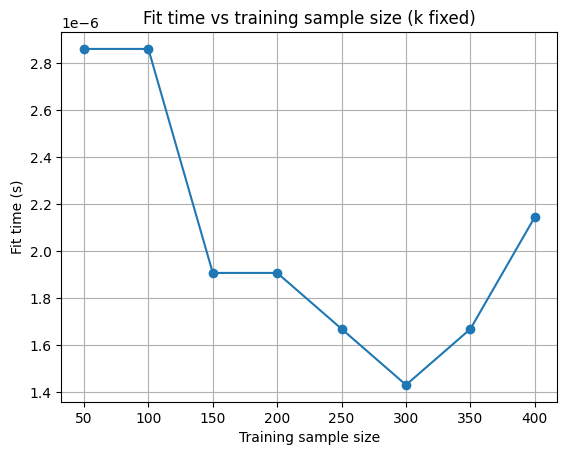

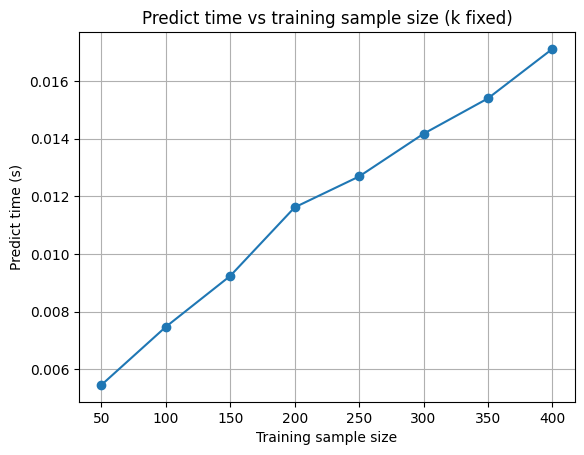

In [14]:

plt.figure()
plt.plot(sizes, fit_times, marker="o")
plt.xlabel("Training sample size")
plt.ylabel("Fit time (s)")
plt.title("Fit time vs training sample size (k fixed)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(sizes, pred_times, marker="o")
plt.xlabel("Training sample size")
plt.ylabel("Predict time (s)")
plt.title("Predict time vs training sample size (k fixed)")
plt.grid(True)
plt.show()

🧠 **Question 4.** Describe and explain the relation between inference time and sample size.

It is clear from the plot that the inference time grows with the sample size. This behaviour was expected since the bigger the sample size is more computations are necessary to give all observations a prediction.


## 5) Train/Test accuracy vs k

Depending on the value of `k`, our classifier may produce different predictions. One way to select a value for the number of neighbors `k` is to analyze the accuracy on the test set.

🔧 **Question 5.** Complete the `for` loop below so that we store the train/test accuracy for several values of `k`

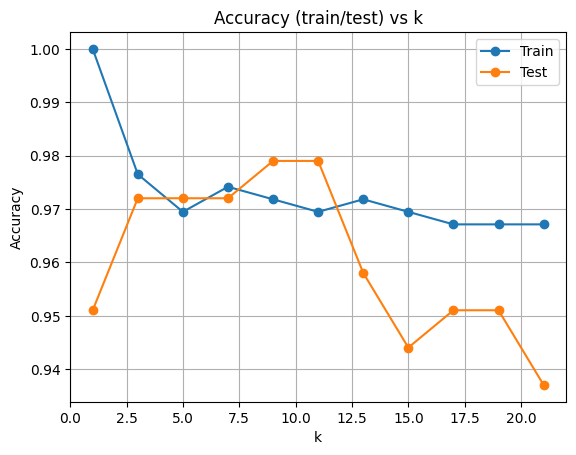

In [6]:
def accuracy(y_true, y_pred):
    return (y_true == y_pred).mean()

ks = np.arange(1, 22, 2)
train_scores = []
test_scores = []

for k in ks:
    knn = KNNClassifier(n_neighbors=int(k))
    # TODO: fit on full training set
    knn.fit(X_train, y_train)
    # TODO: make predictions
    y_tr = knn.predict(X_train)
    y_te = knn.predict(X_test)
    train_scores.append(accuracy(y_train, y_tr))
    test_scores.append(accuracy(y_test, y_te))

plt.figure()
plt.plot(ks, train_scores, marker="o", label="Train")
plt.plot(ks, test_scores, marker="o", label="Test")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy (train/test) vs k")
plt.legend()
plt.grid(True)
plt.show()


🧠 **Question 6.** Discuss the evolution of the train accuracy w.r.t. `k`. Same with the test accuracy. Which value should we pick for `k`?

When k = 1, the classifier only considers the same point as the one it is tring to predict. Thus, it memorizes the training set and the accuracy will be 100%. As k increases, it is possible to see the decrease of train accuracy because the model is distancing itself from the perfect value k = 1.
About test accuracy, when k = 1, the model is overfitted so test accuracy is bad. As k increases, we start to get better accuracies due to the decrease of variance (from k = 1 to k = 11) until a point were the bias is to big ( k = 13). Then, the model starts underfitting and accuracy decreases.
Considering these results, we should choose k = 9 which gives the highest test accuracy.


## 7) Decision boundaries (2D) and overfitting

Another way to notice overfitting is to look at decision boundaries, in particular their smoothness.

🔧 **Question 7.** Complete the `plot_decision_boundary_2d` function so that it fits a 2D projection of the dataset and plot the decision boundary for 3 values of `k` (typically 1, 21 and the value you have picked in **Q6**).


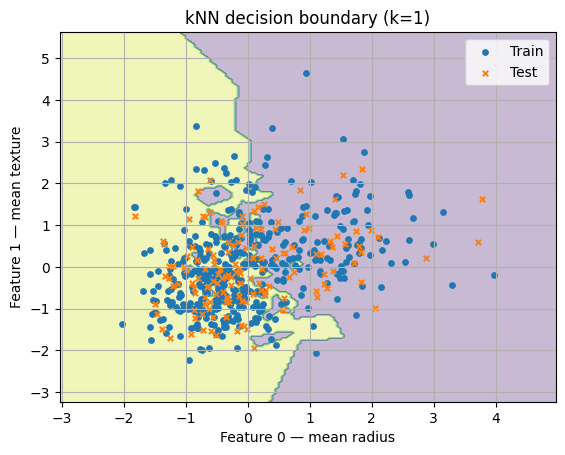

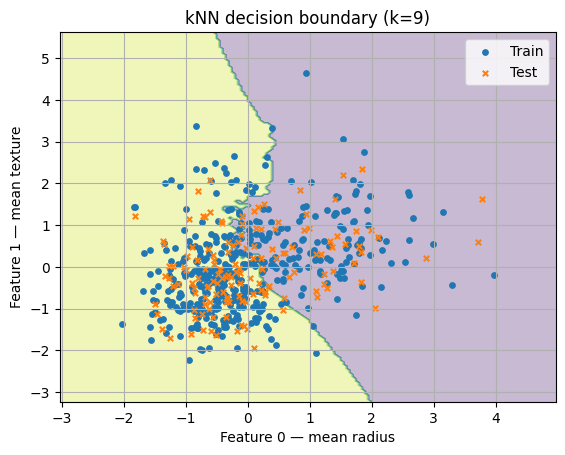

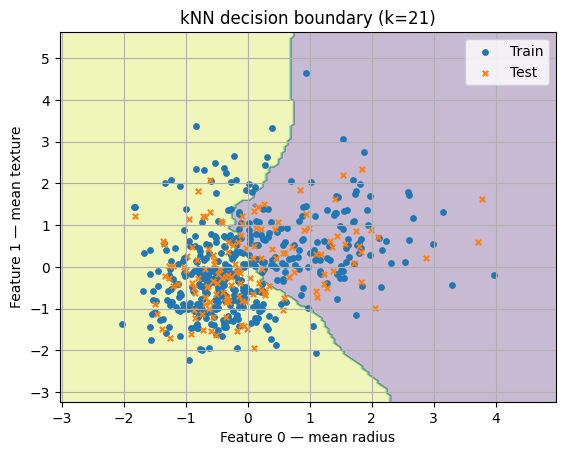

In [7]:
def plot_decision_boundary_2d(X_train, y_train, X_test, y_test, feature_idx=(0,1), k=5, h=0.05):
    i, j = feature_idx
    Xtr = X_train[:, [i, j]]
    Xte = X_test[:, [i, j]]

    knn = KNNClassifier(n_neighbors=k)
    # TODO: fit on 2D projected training data
    knn.fit(Xtr, y_train)

    x_min, x_max = Xtr[:,0].min() - 1.0, Xtr[:,0].max() + 1.0
    y_min, y_max = Xtr[:,1].min() - 1.0, Xtr[:,1].max() + 1.0
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = knn.predict(grid).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(Xtr[:,0], Xtr[:,1], s=15, label="Train")
    plt.scatter(Xte[:,0], Xte[:,1], s=15, marker="x", label="Test")
    plt.xlabel(f"Feature {i} — {feature_names[i]}")
    plt.ylabel(f"Feature {j} — {feature_names[j]}")
    plt.title(f"kNN decision boundary (k={k})")
    plt.legend()
    plt.grid(True)
    plt.show()

# TODO: plot the decision boundary for various values of k
plot_decision_boundary_2d(X_train, y_train, X_test, y_test, k=1)
plot_decision_boundary_2d(X_train, y_train, X_test, y_test, k=9)
plot_decision_boundary_2d(X_train, y_train, X_test, y_test, k=21)

🧠 **Question 8.** Comment the shape of the decision boundary for the different values of `k`.

When k=1, we notice that the decision boundary is really specific to the points, sometimes creating an area that surrounds a single point. This indicates a high variance, small biased model, probably overfitting the data.

As the value of k increases to k=9, we can see the decision boundary becoming smoother, but still maintains some sharp edges. Here, the model captures better the general shape of classes and achieve a balance between bias and variance.

Finally, when k = 21, the decision boundary have almost no sharp edges and start to poorly differentiate the different points. The variance is low and the bias is high, which indicates an underfitting.